# Example use of HBQ in a mini-GRN generator

* Demonstrates a minimal Generative Refinement Network (https://arxiv.org/abs/2604.13030) using this Heirarchical Binary Quantizer.

In [1]:
import hierarchical_binary_quantization.hbq as hbq
import hierarchical_binary_quantization.misc.image_helpers as ih
import lpips
import math, random
import os
import matplotlib.pyplot as plt
import time
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from datetime import datetime
from hierarchical_binary_quantization.misc.checkpoint_helpers import save_checkpoint,load_checkpoint
from hierarchical_binary_quantization.example_autoencoder import ExampleAutoencoder, ExampleQuantizingAutoencoder
from pathlib import Path
from PIL import Image
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision import datasets, transforms
from tqdm.auto import tqdm
from torch.utils.data import Dataset

dataset='fantasy'
autoencoder_cp = 'checkpoints/good/2026-08-04_02:00:00finetune_256_5_bd_96_ld_32_qd_8.pth'
autoencoder_cp = 'checkpoints/good/2026-08-04_23-41-00_256_4_bd_96_ld_32_qd_8.pth'

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
batch_size = 128

## Unconditioned generation of the first bit.

In [2]:
class ImageDataset(Dataset):
    def __init__(self, root, transform=None):
        self.transform = transform
        exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")
        self.files = []
        for ext in exts:
            self.files.extend(Path(root).rglob(ext))
        self.files = sorted(self.files)
        print(f"Found {len(self.files)} images.")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img

target_size = 256
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

train_dataset = ImageDataset(
    root=f"./data/256x256/{dataset}",
    transform=transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

print(f"{len(train_dataset)} training images")
next(iter(train_loader)).shape

Found 12814 images.
12814 training images


torch.Size([128, 3, 256, 256])

In [3]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import torch
from PIL import Image
import numpy as np

def q_out_to_rgb(q_out):
    B, C, H, W = q_out.shape
    rgb_images = []
    for b in range(B):
        # (C,H,W) -> (H*W,C)
        x = q_out[b].permute(1, 2, 0).reshape(-1, C)
        x = x.detach().cpu().numpy()
        rgb = PCA(n_components=3, whiten=True).fit_transform(x)
        rgb -= rgb.min(axis=0, keepdims=True)
        rgb /= rgb.max(axis=0, keepdims=True) + 1e-8
        rgb = torch.from_numpy(rgb.reshape(H, W, 3)).float()
        rgb_images.append(rgb)
    return torch.stack(rgb_images)

def show_reconstructions(model, imgs):
    was_training = model.training
    model.eval()
    with torch.inference_mode():
        reconstructions, aux = model(imgs[:1])
    if was_training:
        model.train()
    original = ih.tensor_to_pil(imgs[0])
    reconstruction = ih.tensor_to_pil(reconstructions[0])
    latent = ih.tensor_to_pil(q_out_to_rgb(aux.quant_info.quantized)[0])
    print(
        f"latent: μ={aux.latents.mean():.3f}  σ={aux.latents.std():.3f}"
    )
    if aux.quant_info.tokens is not None:
        unique = aux.quant_info.tokens.unique().numel()
        print(
            f"unique tokens={unique} out of "
            f"{2**(aux.quant_info.n_rounds * model.config.quant_dim)}."
        )
    h = ih.html_for_images([original, latent, reconstruction])
    return h, original, latent, reconstruction
    


In [4]:
import hierarchical_binary_quantization.misc.checkpoint_helpers as ch
import hierarchical_binary_quantization.example_autoencoder as eae
cp_path = 'checkpoints/good/2026-08-04_23-41-00_256_4_bd_96_ld_32_qd_8.pth'
cfg = ch.check_checkpoint(cp_path)['config']
autoencoder = ExampleQuantizingAutoencoder(**cfg)
optimizer=None
load_checkpoint(autoencoder,optimizer,cp_path)
autoencoder.eval()
autoencoder.to(device)
pass

🔄 Loading checkpoint from checkpoints/good/2026-08-04_23-41-00_256_4_bd_96_ld_32_qd_8.pth
    Model class: ExampleQuantizingAutoencoder
{'in_channels': 3, 'base_dim': 96, 'channel_multipliers': (1, 2, 3, 4), 'res_blocks': (1, 2, 3, 3), 'latent_dim': 32, 'quant_dim': 8, 'n_rounds': 4}
🔄 Loading checkpoint from checkpoints/good/2026-08-04_23-41-00_256_4_bd_96_ld_32_qd_8.pth
    Model class: ExampleQuantizingAutoencoder
{'in_channels': 3, 'base_dim': 96, 'channel_multipliers': (1, 2, 3, 4), 'res_blocks': (1, 2, 3, 3), 'latent_dim': 32, 'quant_dim': 8, 'n_rounds': 4}


In [5]:
import numpy as np
import torch
from pathlib import Path
from torch.utils.data import DataLoader
from torchvision import transforms

from hierarchical_binary_quantization.misc.checkpoint_helpers import load_checkpoint
from hierarchical_binary_quantization.hbq import HBQQuantizer  # adjust import path as needed
# from your_autoencoder_module import ExampleQuantizingAutoencoder

MAX_ROUNDS = 4
CKPT_PATH = autoencoder_cp
SRC_ROOT = Path(f"./data/256x256/{dataset}")
DST_ROOT = Path(f"./data/16x16x8latents/{dataset}")
DST_ROOT = Path(f"./data/32x32x8latents/{dataset}")
TARGET_SIZE = 256
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

class ImageFileDataset(torch.utils.data.Dataset):
    """Like your ImageDataset, but also returns the relative path so we know
    where to write each cached file."""
    def __init__(self, root, transform=None):
        self.root = Path(root)
        self.transform = transform
        exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")
        self.files = []
        for ext in exts:
            self.files.extend(self.root.rglob(ext))
        self.files = sorted(self.files)
        print(f"Found {len(self.files)} images.")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        rel_path = path.relative_to(self.root).with_suffix(".npz")
        return img, str(rel_path)

def collate(batch):
    imgs, rel_paths = zip(*batch)
    return torch.stack(imgs), list(rel_paths)

def generate_token_cache():
    from PIL import Image  # local import so the dataset class above can use it

    transform = transforms.Compose([
        transforms.Resize(TARGET_SIZE),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])

    dataset = ImageFileDataset(SRC_ROOT, transform=transform)
    loader = DataLoader(dataset, batch_size=8, shuffle=False,collate_fn=collate)
    checkpoint = torch.load(CKPT_PATH, map_location="cpu")
    conf = checkpoint["config"]  # assumes this was saved as an HBQAutoencoderConfig or dict
    autoencoder = ExampleQuantizingAutoencoder(**conf).to(DEVICE)
    autoencoder.load_state_dict(checkpoint["model_state_dict"], strict=True)
    autoencoder.eval()
    # force max rounds regardless of what the checkpoint's quantizer was set to
    autoencoder.quantizer = HBQQuantizer(n_rounds=MAX_ROUNDS)

    DST_ROOT.mkdir(parents=True, exist_ok=True)

    with torch.inference_mode():
        for imgs, rel_paths in tqdm(loader):
            imgs = imgs.to(DEVICE)
            _, aux = autoencoder(imgs)
            # aux.bit_codes shape: (B, L, H, W) -- one int per (channel, position),
            # already accumulated so bit_codes >> (MAX_ROUNDS - r) gives the r-round code
            bit_codes = aux.quant_info.bit_codes.to(torch.uint8).cpu().numpy()
            for i, rel_path in enumerate(rel_paths):
                out_path = DST_ROOT / rel_path
                out_path.parent.mkdir(parents=True, exist_ok=True)
                np.savez_compressed(out_path, bit_codes=bit_codes[i])

    print(f"Cached {len(dataset)} latents to {DST_ROOT}")

if not os.path.exists(DST_ROOT):
    generate_token_cache()

In [6]:
print(np.load('data/32x32x8latents/fantasy/img/012813.npz')['bit_codes'].shape)
print("first latent element for all cells:\n", np.load('data/32x32x8latents/fantasy/img/012813.npz')['bit_codes'][0])
print("top left latent: ", np.load('data/16x16x8latents/fantasy/img/012813.npz')['bit_codes'][:,0,0])


(8, 32, 32)
first latent element for all cells:
 [[15  1  5 ...  8 11  1]
 [15  0  0 ...  4  7  1]
 [15  0  4 ...  9 15  0]
 ...
 [ 2  2  2 ...  2  6  0]
 [ 2  3  2 ...  3  1  4]
 [ 1  3  2 ...  1  2  4]]
top left latent:  [14 15 15  0  5 12 12  1]


In [7]:
import numpy as np
import torch
from pathlib import Path
from torch.utils.data import Dataset

from hierarchical_binary_quantization.hbq import bit_codes_to_tokens  # adjust import path as needed

class HBQTokenDataset(Dataset):
    """Loads cached full-resolution bit_codes and collapses them to single-int
    tokens at a fixed round count. Shape returned: (H, W) int64, values in [0, 2^(L*n_rounds))."""

    def __init__(self, root, n_rounds: int, max_rounds: int = 4):
        self.root = Path(root)
        self.n_rounds = n_rounds
        self.max_rounds = max_rounds
        self.files = sorted(self.root.rglob("*.npz"))
        print(f"Found {len(self.files)} cached latents.")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx])
        bit_codes = torch.from_numpy(data["bit_codes"].astype(np.int64))  # (L, H, W)
        # slice down from max_rounds to n_rounds (top n_rounds bits)
        bit_codes = bit_codes >> (self.max_rounds - self.n_rounds)
        # (L, H, W) -> (H, W, L) to match bit_codes_to_tokens's expected layout
        bit_codes = bit_codes.permute(1, 2, 0)
        tokens = bit_codes_to_tokens(bit_codes, self.n_rounds)  # (H, W)
        return tokens


In [8]:
ds = HBQTokenDataset(f'data/32x32x8latents/{dataset}/img',1)
dl = DataLoader(ds)
(ds[0].shape,ds[0].max)


Found 12814 cached latents.


(torch.Size([32, 32]), <function Tensor.max>)

In [9]:
import torch
import torch.nn.functional as F
import math

@torch.inference_mode()
def sample(model, batch_size=4, n_steps=8, grid_size=32, temperature=1.0, device="cpu"):
    N = grid_size * grid_size
    tokens = torch.full((batch_size, grid_size, grid_size), model.mask_id, dtype=torch.long, device=device)
    is_masked = torch.ones(batch_size, grid_size, grid_size, dtype=torch.bool, device=device)

    # cosine schedule: how many positions should be *committed* (non-masked) by the end of step t
    for step in range(n_steps):
        logits = model(tokens)                                    # (B, H, W, vocab)
        probs = F.softmax(logits / temperature, dim=-1)

        flat_probs = probs.view(batch_size * N, -1)
        sampled = torch.multinomial(flat_probs, num_samples=1).view(batch_size, grid_size, grid_size)
        confidence = flat_probs.gather(1, sampled.view(-1, 1)).view(batch_size, grid_size, grid_size)

        # how many positions total should be committed after this step (cosine schedule, more each step)
        frac_committed = 1.0 - math.cos((step + 1) / n_steps * math.pi / 2)  # 0 -> 1 across steps
        n_target_committed = int(frac_committed * N)

        for b in range(batch_size):
            n_currently_committed = N - is_masked[b].sum().item()
            n_to_commit = max(0, n_target_committed - n_currently_committed)
            if n_to_commit == 0:
                continue

            # only rank confidence among still-masked positions
            masked_conf = confidence[b].clone()
            masked_conf[~is_masked[b]] = -1.0  # exclude already-committed positions
            flat_conf = masked_conf.view(-1)
            topk = torch.topk(flat_conf, k=min(n_to_commit, is_masked[b].sum().item()))
            chosen_idx = topk.indices  # flat indices into the grid

            flat_tokens = tokens[b].view(-1)
            flat_sampled = sampled[b].view(-1)
            flat_is_masked = is_masked[b].view(-1)
            flat_tokens[chosen_idx] = flat_sampled[chosen_idx]
            flat_is_masked[chosen_idx] = False

    # anything left masked after the loop (shouldn't happen if schedule reaches N) - force-fill
    tokens[is_masked] = sampled[is_masked]
    return tokens

@torch.inference_mode()
def sample(model, batch_size=4, n_steps=8, grid_size=32, temperature=1.0, device="cpu"):
    N = grid_size * grid_size
    tokens = torch.full((batch_size, grid_size, grid_size), model.vocab_size, dtype=torch.long, device=device)
    is_masked = torch.ones(batch_size, grid_size, grid_size, dtype=torch.bool, device=device)

    # cosine schedule: how many positions should be *committed* (non-masked) by the end of step t
    for step in range(n_steps):
        logits = model(tokens, is_masked)                                    # (B, H, W, vocab)
        probs = F.softmax(logits / temperature, dim=-1)

        flat_probs = probs.view(batch_size * N, -1)
        sampled = torch.multinomial(flat_probs, num_samples=1).view(batch_size, grid_size, grid_size)
        confidence = flat_probs.gather(1, sampled.view(-1, 1)).view(batch_size, grid_size, grid_size)

        # how many positions total should be committed after this step (cosine schedule, more each step)
        frac_committed = 1.0 - math.cos((step + 1) / n_steps * math.pi / 2)  # 0 -> 1 across steps
        n_target_committed = int(frac_committed * N)

        for b in range(batch_size):
            n_currently_committed = N - is_masked[b].sum().item()
            n_to_commit = max(0, n_target_committed - n_currently_committed)
            if n_to_commit == 0:
                continue

            # only rank confidence among still-masked positions
            masked_conf = confidence[b].clone()
            masked_conf[~is_masked[b]] = -1.0  # exclude already-committed positions
            flat_conf = masked_conf.view(-1)
            topk = torch.topk(flat_conf, k=min(n_to_commit, is_masked[b].sum().item()))
            chosen_idx = topk.indices  # flat indices into the grid

            flat_tokens = tokens[b].view(-1)
            flat_sampled = sampled[b].view(-1)
            flat_is_masked = is_masked[b].view(-1)
            flat_tokens[chosen_idx] = flat_sampled[chosen_idx]
            flat_is_masked[chosen_idx] = False

    # anything left masked after the loop (shouldn't happen if schedule reaches N) - force-fill
    tokens[is_masked] = sampled[is_masked]
    return tokens


## transformer predicter model

In [10]:
import math
import torch
import torch.nn as nn

class MaskedTokenTransformer(nn.Module):
    def __init__(self, vocab_size=256, grid_size=32, dim=128, n_heads=4, n_layers=4, ff_dim=512, dropout=0.1):
        super().__init__()
        self.grid_size = grid_size
        self.n_positions = grid_size * grid_size
        self.mask_id = vocab_size  # one extra embedding slot for [MASK]

        self.token_embed = nn.Embedding(vocab_size + 1, dim)
        self.pos_embed = nn.Parameter(torch.randn(1, self.n_positions, dim) * 0.02)

        layer = nn.TransformerEncoderLayer(
            d_model=dim, nhead=n_heads, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.norm_out = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, vocab_size)  # predicts real tokens only, never [MASK]

    def forward(self, tokens):  # tokens: (B, H, W), int64, may contain mask_id
        B = tokens.shape[0]
        x = tokens.view(B, -1)                # (B, N)
        x = self.token_embed(x) + self.pos_embed
        x = self.encoder(x)
        x = self.norm_out(x)
        logits = self.head(x)                 # (B, N, vocab_size)
        return logits.view(B, self.grid_size, self.grid_size, -1)



class MaskedTokenTransformer(nn.Module):
    def __init__(self, latent_dim=8, vocab_size=256, grid_size=32, dim=128,
                 n_heads=4, n_layers=4, ff_dim=512, dropout=0.1):
        super().__init__()
        self.grid_size = grid_size
        self.n_positions = grid_size * grid_size
        self.vocab_size = vocab_size
        self.latent_dim = latent_dim
        self.mask_embed = nn.Parameter(torch.randn(dim) * 0.02)

        self.token_proj = nn.Linear(latent_dim, dim)   # replaces nn.Embedding
        self.pos_embed = nn.Parameter(torch.randn(1, self.n_positions, dim) * 0.02)

        layer = nn.TransformerEncoderLayer(
            d_model=dim, nhead=n_heads, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.norm_out = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, vocab_size)

    def forward(self, tokens, is_masked):
        # tokens: (B, H, W) int, real token ids at unmasked positions (masked values ignored)
        # is_masked: (B, H, W) bool
        B = tokens.shape[0]
        n_rounds = 1  # first-bit model always round=1

        # dequantize known tokens to float latents
        bit_codes = tokens_to_bit_codes(tokens, latent_dim=self.latent_dim, n_rounds=n_rounds)  # (B,H,W,L)
        quantized = bit_codes_to_quantized_latent(bit_codes, n_rounds=n_rounds)                  # (B,H,W,L)

        projected = self.token_proj(quantized.view(B, self.n_positions, -1))                     # (B,N,dim)

        # substitute mask embedding at masked positions
        mask_flat = is_masked.view(B, self.n_positions, 1).float()
        x = projected * (1 - mask_flat) + self.mask_embed.view(1, 1, -1) * mask_flat

        x = x + self.pos_embed
        x = self.encoder(x)
        x = self.norm_out(x)
        logits = self.head(x)
        return logits.view(B, self.grid_size, self.grid_size, -1)

In [11]:
def mask_batch(tokens, mask_id):
    B, H, W = tokens.shape
    N = H * W
    flat = tokens.view(B, N)

    # cosine schedule: r in (0, 1], skewed toward higher mask ratios
    u = torch.rand(B, device=tokens.device)
    ratio = torch.cos(u * math.pi / 2)                     # r in (0, 1]
    n_mask = (ratio * N).clamp(min=1).long()                # at least 1 masked per example

    masked = flat.clone()
    mask_bool = torch.zeros(B, N, dtype=torch.bool, device=tokens.device)
    for b in range(B):
        idx = torch.randperm(N, device=tokens.device)[:n_mask[b]]
        mask_bool[b, idx] = True
    masked[mask_bool] = mask_id
    return masked.view(B, H, W), mask_bool.view(B, H, W)


In [12]:
import torch
import matplotlib.pyplot as plt

from hierarchical_binary_quantization.hbq import tokens_to_bit_codes, bit_codes_to_quantized_latent
autoencoder.to("cpu")
@torch.inference_mode()
def decode_tokens(autoencoder, tokens, latent_dim=8, n_rounds=1, device="cpu"):
    """tokens: (B, H, W) int64 from the sampling loop.
    Returns images in [0,1], shape (B, C, H_img, W_img)."""
    tokens = tokens.to(device)
    # (B, H, W) -> (B, H, W, L) bit codes at the given round count
    bit_codes = tokens_to_bit_codes(tokens, latent_dim=latent_dim, n_rounds=n_rounds)
    # dequantize: (B, H, W, L) -> same shape, float
    quantized = bit_codes_to_quantized_latent(bit_codes, n_rounds=n_rounds)
    # rearrange to the (B, L, H, W) channel-first layout the decoder expects
    quantized = quantized.permute(0, 3, 1, 2).contiguous()
    # run through post_quant + decoder, same as the autoencoder's forward pass
    z = autoencoder.post_quant(quantized)
    images = autoencoder.backbone.decode(z)
    images = images
    return images.cpu()

import IPython.display as ipd
def show_grid(images, ncols=4):
    n = images.shape[0]
    imgs = [ih.tensor_to_pil(t) for t in images]
    h = ih.html_for_images(imgs,min_height=128)
    ipd.display(ipd.HTML(h))


In [13]:
mtt = MaskedTokenTransformer()
mtt.to('cuda')
optimizer = torch.optim.AdamW(mtt.parameters(), lr=3e-4, weight_decay=1e-4)


0.7015080451965332 0 0 128 5.584123134613037



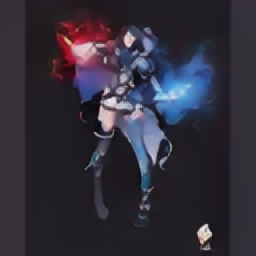


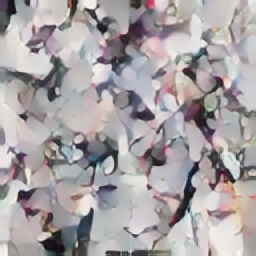
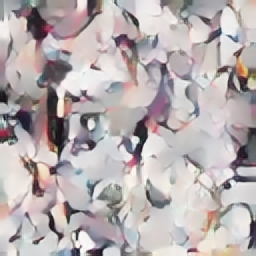
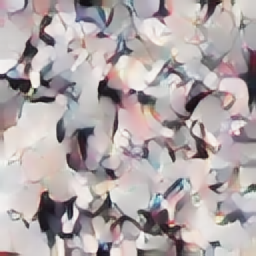
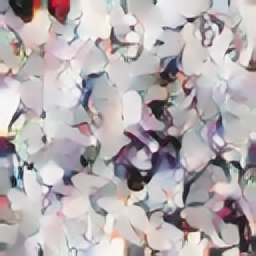

5.711103439331055 0 5 128 4.976367473602295



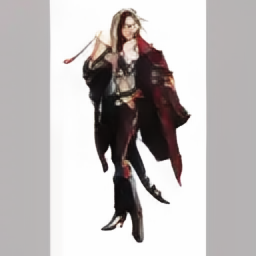


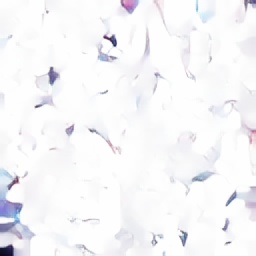
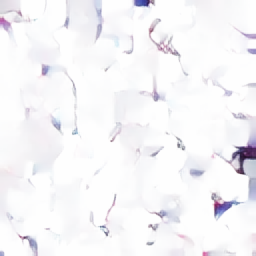
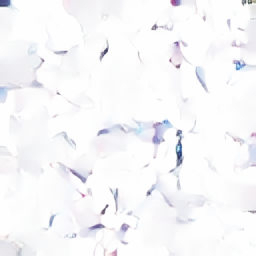
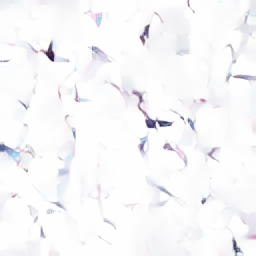

13.567258834838867 0 18 128 4.524959564208984



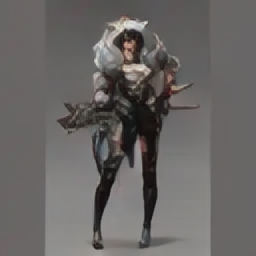

Warning - this project defaults to +/- 1 for most tensors



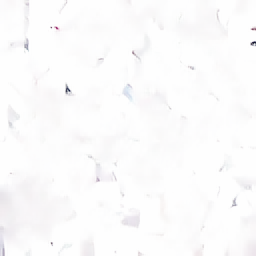
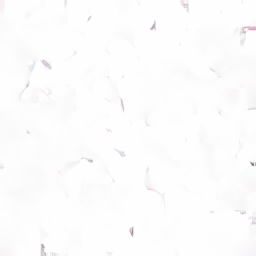
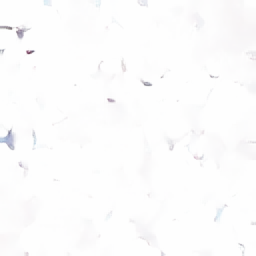
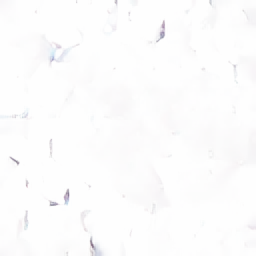

24.887746810913086 0 39 128 4.199099540710449



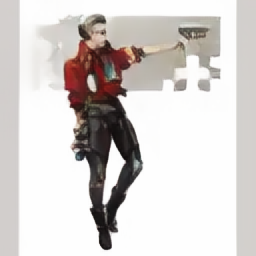

Warning - this project defaults to +/- 1 for most tensors
Warning - this project defaults to +/- 1 for most tensors



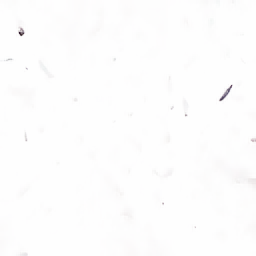
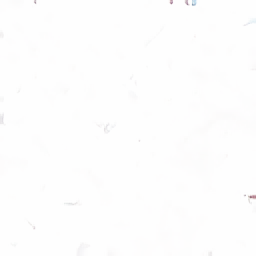
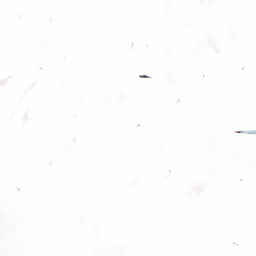
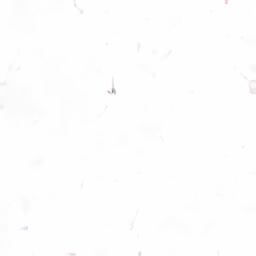

41.883580923080444 0 75 128 3.9835140705108643



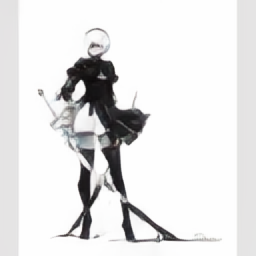


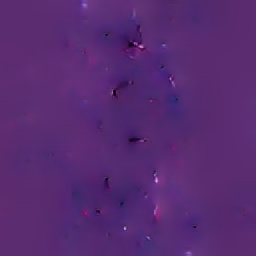
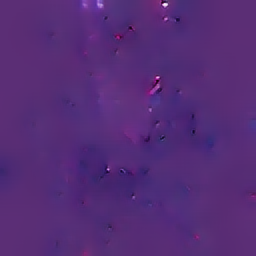
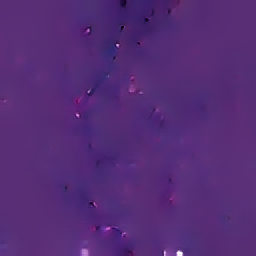
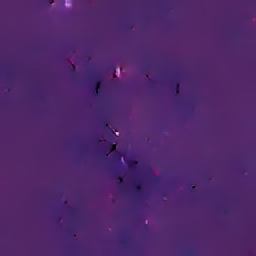

67.3158507347107 1 132 128 3.598130941390991



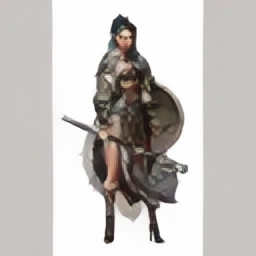

Warning - this project defaults to +/- 1 for most tensors



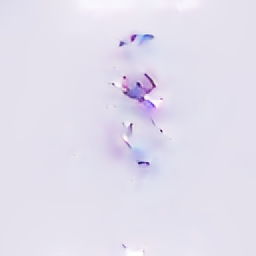
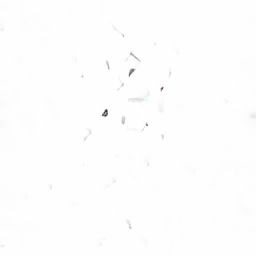
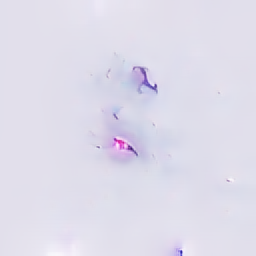
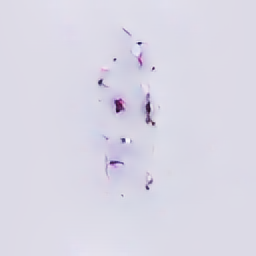

105.4958336353302 2 222 128 3.443821430206299



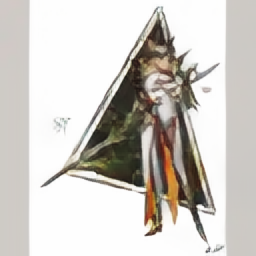


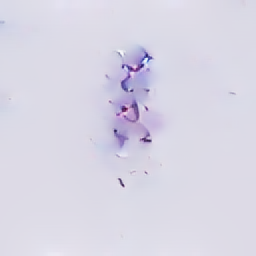
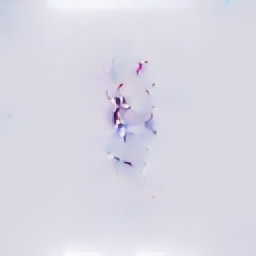
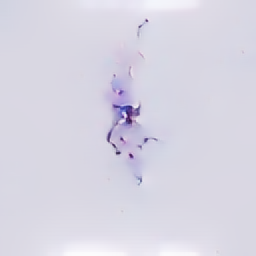
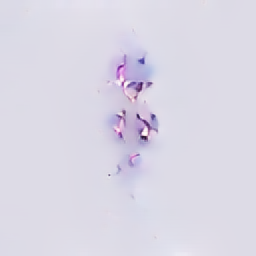

162.5550012588501 3 359 128 3.3659820556640625



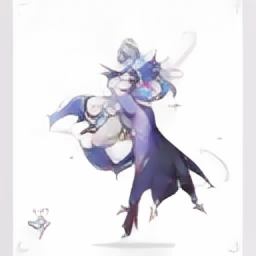


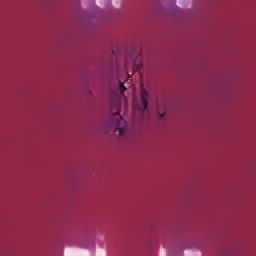
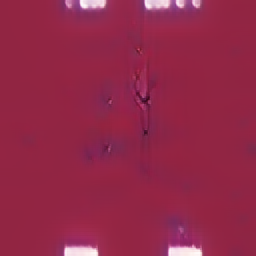
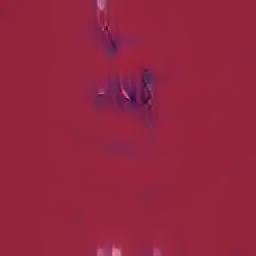
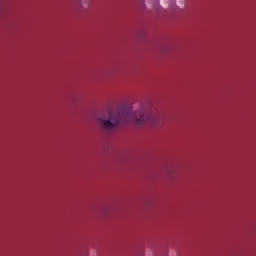

248.31964993476868 5 567 128 3.277094602584839



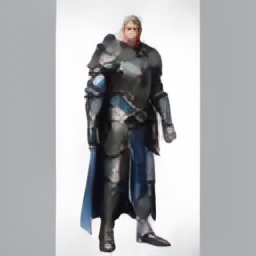


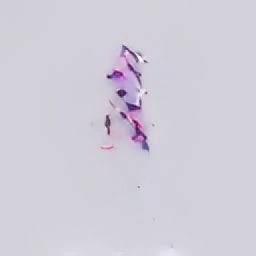
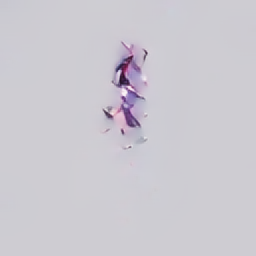
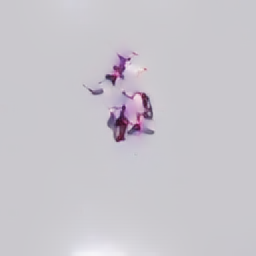
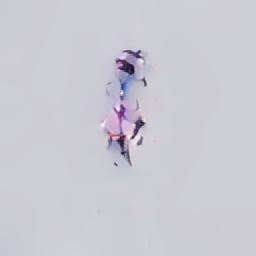

376.8088917732239 8 883 128 3.27455472946167



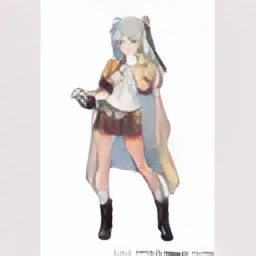


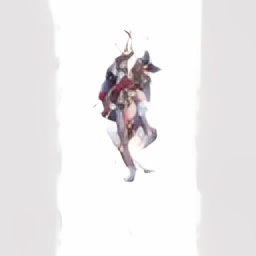
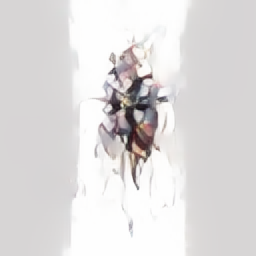
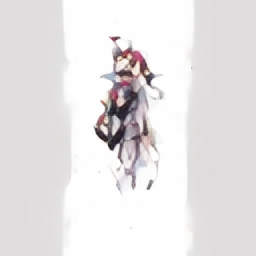
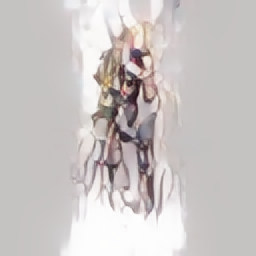

569.335428237915 13 1363 128 2.9450953006744385



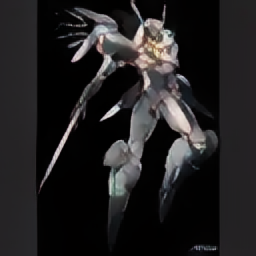


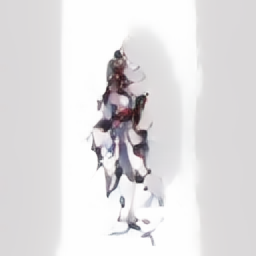
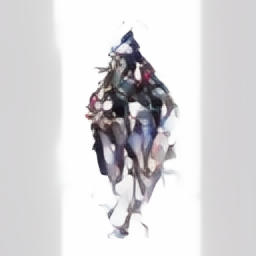
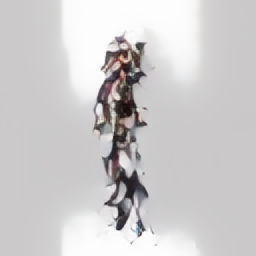
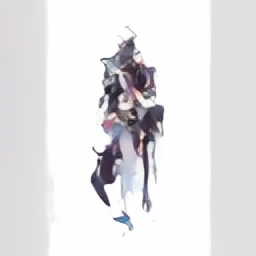

In [ ]:
dl = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=0)
t0=time.time()
display_interval, next_display_time = 5,0

n_epochs = 4000  # tune based on dataset size / how fast loss settles
step = 0

# def train_step(model, tokens, optimizer):
#     masked_tokens, mask_bool = mask_batch(tokens, model.mask_id)
#     logits = model(masked_tokens)                            # (B, H, W, vocab)
#     loss = nn.functional.cross_entropy(
#         logits[mask_bool], tokens[mask_bool]                  # only score masked positions
#     )
#     optimizer.zero_grad()
#     loss.backward()
#     optimizer.step()
#     return loss.item()
    
#try:
if False:
    mtt.to('cuda')
    scaler = torch.amp.GradScaler('cuda')
    for epoch in range(n_epochs):
        for tokens in dl:              # new, shuffled batch every step within the epoch
            tokens = tokens.to(device)
            #loss = train_step(mtt, tokens.to('cuda'), optimizer)
            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                 masked_tokens, mask_bool = mask_batch(tokens, mtt.mask_id)
                 logits = mtt(masked_tokens)                            # (B, H, W, vocab)
                 loss = nn.functional.cross_entropy(
                     logits[mask_bool], tokens[mask_bool]                  # only score masked positions
                 )
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            if time.time() > next_display_time:
                print(time.time()-t0, epoch, step, batch_size, loss.item())
                next_display_time = time.time() + display_interval
                display_interval = min(display_interval * 1.5, 60*30)
                results = decode_tokens(autoencoder, tokens[0:1])
                show_grid(results)
                results = decode_tokens(autoencoder, sample(mtt,temperature=1,device='cuda'))
                show_grid(results)
            step += 1

if True:
    mtt.to('cuda')
    scaler = torch.amp.GradScaler('cuda')
    for epoch in range(n_epochs):
        for tokens in dl:              # new, shuffled batch every step within the epoch
            tokens = tokens.to(device)
            #loss = train_step(mtt, tokens.to('cuda'), optimizer)
            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                 masked_tokens, mask_bool = mask_batch(tokens, mtt.vocab_size) # mask_id = vocab_size, unused in embed now
                 logits = mtt(masked_tokens, mask_bool)                            # (B, H, W, vocab)
                 loss = nn.functional.cross_entropy(
                     logits[mask_bool], tokens[mask_bool]                  # only score masked positions
                 )
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            if time.time() > next_display_time:
                print(time.time()-t0, epoch, step, batch_size, loss.item())
                next_display_time = time.time() + display_interval
                display_interval = min(display_interval * 1.5, 60*5)
                results = decode_tokens(autoencoder, tokens[0:1])
                show_grid(results)
                results = decode_tokens(autoencoder, sample(mtt,temperature=1,device='cuda'))
                show_grid(results)
            step += 1

#except KeyboardInterrupt as e:
    #print("Done")


In [ ]:
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
mtt.config={'TODO':"create config"}
save_checkpoint(f"checkpoints/mtt_{timestamp}_32x32x8.pth",mtt,None)

In [ ]:
mtt.to("cpu")
for temp in np.arange(0.1,2.1,0.1):
    print(temp)
    results = decode_tokens(autoencoder, sample(mtt,temperature=temp),device="cpu")
    #ipd.display(ipd.HTML(results))
    show_grid(results)

## Generative Refinement

In [ ]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from torch.utils.data import Dataset, DataLoader

from hierarchical_binary_quantization.hbq import (
    bit_codes_to_tokens, tokens_to_bit_codes, bit_codes_to_quantized_latent,
)

# ---------- Dataset ----------

class ConditionedDeltaDataset(Dataset):
    def __init__(self, root, prev_rounds: int, max_rounds: int = 4):
        self.root = Path(root)
        self.prev_rounds = prev_rounds
        self.max_rounds = max_rounds
        self.files = sorted(self.root.rglob("*.npz"))
        print(f"Found {len(self.files)} cached latents.")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx])
        bit_codes = torch.from_numpy(data["bit_codes"].astype(np.int64))  # (L, H, W)

        prev_bits = bit_codes >> (self.max_rounds - self.prev_rounds)
        delta_bits = (bit_codes >> (self.max_rounds - self.prev_rounds - 1)) & 1

        prev_bits_hwl = prev_bits.permute(1, 2, 0)
        delta_bits_hwl = delta_bits.permute(1, 2, 0)

        context_latent = bit_codes_to_quantized_latent(prev_bits_hwl, n_rounds=self.prev_rounds)
        delta_tokens = bit_codes_to_tokens(delta_bits_hwl, n_rounds=1)
        prev_tokens = bit_codes_to_tokens(prev_bits_hwl, n_rounds=self.prev_rounds)

        return context_latent, delta_tokens, prev_tokens, bit_codes  # bit_codes: (L, H, W), full max_rounds


# ---------- Model ----------

class ConditionedMaskedTokenTransformer(nn.Module):
    def __init__(self, latent_dim=8, vocab_size=256, grid_size=16, dim=128,
                 n_heads=4, n_layers=4, ff_dim=512, dropout=0.1):
        super().__init__()
        self.grid_size = grid_size
        self.n_positions = grid_size * grid_size
        self.mask_id = vocab_size

        self.context_proj = nn.Linear(latent_dim, dim)          # continuous, fixed size regardless of round depth
        self.target_embed = nn.Embedding(vocab_size + 1, dim)   # delta token + [MASK]
        self.pos_embed = nn.Parameter(torch.randn(1, self.n_positions, dim) * 0.02)

        layer = nn.TransformerEncoderLayer(
            d_model=dim, nhead=n_heads, dim_feedforward=ff_dim,
            dropout=dropout, batch_first=True, activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.norm_out = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, vocab_size)

    def forward(self, context_latent, target_tokens):
        # context_latent: (B, H, W, L) float; target_tokens: (B, H, W) int, may contain mask_id
        B = context_latent.shape[0]
        ctx = self.context_proj(context_latent.view(B, self.n_positions, -1))
        tgt = self.target_embed(target_tokens.view(B, -1))
        x = ctx + tgt + self.pos_embed
        x = self.encoder(x)
        x = self.norm_out(x)
        logits = self.head(x)
        return logits.view(B, self.grid_size, self.grid_size, -1)


# ---------- Masking (unchanged from round-1) ----------

def mask_batch(tokens, mask_id):
    B, H, W = tokens.shape
    N = H * W
    flat = tokens.view(B, N)

    u = torch.rand(B, device=tokens.device)
    ratio = torch.cos(u * math.pi / 2)
    n_mask = (ratio * N).clamp(min=1).long()

    masked = flat.clone()
    mask_bool = torch.zeros(B, N, dtype=torch.bool, device=tokens.device)
    for b in range(B):
        idx = torch.randperm(N, device=tokens.device)[:n_mask[b]]
        mask_bool[b, idx] = True
    masked[mask_bool] = mask_id
    return masked.view(B, H, W), mask_bool.view(B, H, W)


# ---------- Training ----------

def train_step_conditioned(model, context_latent, delta_tokens, optimizer):
    masked_delta, mask_bool = mask_batch(delta_tokens, model.mask_id)
    logits = model(context_latent, masked_delta)
    loss = F.cross_entropy(logits[mask_bool], delta_tokens[mask_bool])
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()


# ---------- Sampling (context fixed for the whole loop; only delta iterates) ----------

@torch.inference_mode()
def sample_conditioned(model, context_latent, n_steps=8, temperature=1.0, device="cpu"):
    B, H, W, _ = context_latent.shape
    N = H * W
    delta = torch.full((B, H, W), model.mask_id, dtype=torch.long, device=device)
    is_masked = torch.ones(B, H, W, dtype=torch.bool, device=device)

    for step in range(n_steps):
        logits = model(context_latent, delta)
        probs = F.softmax(logits / temperature, dim=-1)

        flat_probs = probs.view(B * N, -1)
        sampled = torch.multinomial(flat_probs, num_samples=1).view(B, H, W)
        confidence = flat_probs.gather(1, sampled.view(-1, 1)).view(B, H, W)

        frac_committed = 1.0 - math.cos((step + 1) / n_steps * math.pi / 2)
        n_target_committed = int(frac_committed * N)

        for b in range(B):
            n_currently_committed = N - is_masked[b].sum().item()
            n_to_commit = max(0, n_target_committed - n_currently_committed)
            if n_to_commit == 0:
                continue
            masked_conf = confidence[b].clone()
            masked_conf[~is_masked[b]] = -1.0
            flat_conf = masked_conf.view(-1)
            topk = torch.topk(flat_conf, k=min(n_to_commit, is_masked[b].sum().item()))
            chosen_idx = topk.indices

            flat_delta = delta[b].view(-1)
            flat_sampled = sampled[b].view(-1)
            flat_is_masked = is_masked[b].view(-1)
            flat_delta[chosen_idx] = flat_sampled[chosen_idx]
            flat_is_masked[chosen_idx] = False

    delta[is_masked] = sampled[is_masked]
    return delta  # (B, H, W) tokens, vocab 256


# ---------- Decode: combine context round + predicted delta into round=prev+1, then to pixels ----------

@torch.inference_mode()
def decode_conditioned(autoencoder, prev_tokens, delta_tokens, latent_dim=8, prev_rounds=1, device="cpu"):
    """prev_tokens: (B, H, W) tokens at prev_rounds (e.g. real round-1, vocab 256).
    delta_tokens: (B, H, W) tokens, the new bit, vocab 256.
    Returns images in [0,1]."""
    prev_tokens = prev_tokens.to(device)
    delta_tokens = delta_tokens.to(device)

    prev_bits = tokens_to_bit_codes(prev_tokens, latent_dim=latent_dim, n_rounds=prev_rounds)  # (B,H,W,L)
    delta_bits = tokens_to_bit_codes(delta_tokens, latent_dim=latent_dim, n_rounds=1)           # (B,H,W,L)

    full_bits = (prev_bits << 1) | delta_bits  # (B,H,W,L), values 0-3 at round=2

    quantized = bit_codes_to_quantized_latent(full_bits, n_rounds=prev_rounds + 1)  # (B,H,W,L) float
    quantized = quantized.permute(0, 3, 1, 2).contiguous()  # (B,L,H,W)

    z = autoencoder.post_quant(quantized)
    images = autoencoder.backbone.decode(z)
    images = (images / 2 + 0.5).clamp(0, 1)
    return images.cpu()



@torch.inference_mode()
def decode_all_levels(autoencoder, bit_codes, max_rounds=4, device="cpu"):
    """bit_codes: (B, L, H, W) int, full-resolution accumulated codes.
    Returns {round: images (B, C, H, W) in [0,1]} for round in 1..max_rounds."""
    bit_codes = bit_codes.to(device)
    results = {}
    for r in range(1, max_rounds + 1):
        r_bits = bit_codes >> (max_rounds - r)                    # (B, L, H, W)
        r_bits = r_bits.permute(0, 2, 3, 1)                        # (B, H, W, L)
        quantized = bit_codes_to_quantized_latent(r_bits, n_rounds=r)
        quantized = quantized.permute(0, 3, 1, 2).contiguous()     # (B, L, H, W)
        z = autoencoder.post_quant(quantized)
        images = autoencoder.backbone.decode(z)
        images = (images / 2 + 0.5).clamp(0, 1)
        results[r] = images.cpu()
    return results

In [ ]:
ds = ConditionedDeltaDataset("data/16x16x8latents/fantasy/img", prev_rounds=1)
dl = DataLoader(ds, batch_size=32, shuffle=True)

model = ConditionedMaskedTokenTransformer(latent_dim=8).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
t0 = time.time()
step = 0
try:
    for epoch in range(50):
        for context_latent, delta_tokens, _, _ in dl:      # prev_tokens unused during training
            loss = train_step_conditioned(model, context_latent.to(device), delta_tokens.to(device), optimizer)
            if step % 1000 == 0:
                print(time.time()-t0, epoch, step, loss)
            step += 1
except KeyboardInterrupt as e:
    print("Done")

# --- sanity check: predict delta given REAL round-1 context ---
context_latent, real_delta, _, _ = next(iter(dl))          # real ground truth, for comparison
pred_delta = sample_conditioned(model, context_latent.to('device), n_steps=8)

# recover round-1 tokens from context_latent's originating bits for decode_conditioned
# (simplest: reload prev tokens from the same cached files rather than re-deriving from context_latent)

In [ ]:
# context_latent, real_delta, _, _ = next(iter(dl))          # real ground truth, for comparison
# pred_delta = sample_conditioned(model, context_latent.to(device), n_steps=8,device=device)
model.eval()
model.to('cpu')
# --- sanity check: predict delta given REAL round-1 context ---
context_latent, real_delta, _, _ = next(iter(dl))          # real ground truth, for comparison
pred_delta = sample_conditioned(model, context_latent.to('cpu'), n_steps=8)


In [ ]:
# --- sanity check: predict delta given REAL round-1 context ---
ds = ConditionedDeltaDataset("data/16x16x8latents/fantasy/img", prev_rounds=1)
dl = DataLoader(ds, batch_size=32, shuffle=True)
device='cpu'
context_latent, real_delta, prev_tokens, bit_codes = next(iter(dl))
pred_delta = sample_conditioned(model, context_latent.to('cpu'), n_steps=8,device=device)
autoencoder.to('cpu')
images_pred = decode_conditioned(autoencoder, prev_tokens, pred_delta, latent_dim=8, prev_rounds=1,device=device)
images_true = decode_conditioned(autoencoder, prev_tokens, real_delta, latent_dim=8, prev_rounds=1,device=device)

#z = autoencoder.post_quant(context_latent.to(device))
#z = autoencoder.backbone.decode(z)
#z = autoencoder.post_quant(context_latent.permute(0, 3, 1, 2).to(device))
z = autoencoder.post_quant(context_latent.permute(0, 3, 1, 2).to('cpu'))
z = autoencoder.backbone.decode(z)
zimgs = [ih.tensor_to_pil(i) for i in z[0:4]]
ipd.display(ipd.HTML(ih.html_for_images(zimgs,title="z",min_height=128)))




In [ ]:
context_latent, real_delta, prev_tokens, bit_codes = next(iter(dl))
context_latent=context_latent.to(device)
pred_delta = sample_conditioned(model, context_latent, n_steps=8,device=device)

images_pred = decode_conditioned(autoencoder, prev_tokens, pred_delta, latent_dim=8, prev_rounds=1,device=device)
images_true = decode_conditioned(autoencoder, prev_tokens, real_delta, latent_dim=8, prev_rounds=1,device=device)
levels = decode_all_levels(autoencoder, bit_codes, max_rounds=4,device=device)  # levels[1], levels[2], levels[3], levels[4]

all_imgs = [levels[1][0], levels[2][0], levels[3][0], levels[4][0], images_pred[0], images_true[0]]
titles = ["round1", "round2", "round3", "round4", "pred delta", "true delta"]
zimgs = [ih.tensor_to_pil(i) for i in all_imgs]
ipd.display(ipd.HTML(ih.html_for_images(zimgs, title=" / ".join(titles), min_height=128)))

In [ ]:
pred = [ih.tensor_to_pil(i) for i in images_pred[0:4]]
real = [ih.tensor_to_pil(i) for i in images_true[0:4]]
ipd.display(ipd.HTML(ih.html_for_images(pred,title="pred",min_height=128)))
ipd.display(ipd.HTML(ih.html_for_images(real,title="real",min_height=128)))

In [ ]:
# imgs = next(iter(train_loader))
# model = autoencoder
# def try_quant_level(n_rounds):
#     model.eval()
#     different_quant = hbq.HBQQuantizer(n_rounds=n_rounds)
#     model.quantizer=different_quant
#     with torch.inference_mode():
#         reconstructions, aux = model(imgs[:1].to(device))
    
#     latents = aux.latents 
#     original = (imgs[0].detach().cpu().permute(1,2,0)/2+0.5).clamp(0,1)
#     with torch.inference_mode():
#         z1 = model.pre_quant(latents)
#         z2 = different_quant(z1)[0]
#         #z2 = (torch.tanh(z1)+ torch.rand(1, 4, 32, 32).to(device)-0.5).clamp(-1,1)
#         #z2 = z1.clamp(-1,1)
#         reconstructions = model.backbone.decode(model.post_quant(z2))
#     reconstruction = (reconstructions[0].detach().cpu().permute(1,2,0)/2+0.5).clamp(0,1)
#     latent_rgb = q_out_to_rgb(aux.quant_info.quantized)[0]
    
#     fig, axes = plt.subplots(1, 3, figsize=(6,2))
    
#     axes[0].imshow(original)
#     axes[0].set_title("Original")
#     axes[0].axis("off")
    
#     axes[1].imshow(latent_rgb)
#     axes[1].set_title("Quantized Latent (PCA)")
#     axes[1].axis("off")
    
#     axes[2].imshow(reconstruction)
#     axes[2].set_title("Reconstruction")
#     axes[2].axis("off")
    
#     plt.tight_layout()
#     plt.show()
    
#     # Nice debugging stats
#     print(
#         f"latent: μ={aux.latents.mean():.3f}  σ={aux.latents.std():.3f}   "
#     )
#     if aux.quant_info.tokens is not None:
#         unique = aux.quant_info.tokens.unique().numel()
#         print(
#                 f"unique tokens={unique} out of {2**(aux.quant_info.n_rounds * model.config.quant_dim)}."
#         )
# try_quant_level(1)
# try_quant_level(2)
# try_quant_level(3)
# try_quant_level(99)